## GERMAN CREDIT DATASET


This notebook shows all the processing done in order to have the cleaned dataset used in the experiment phase. he dataset has been binarized using the processing techniques described in the experiment phase of the paper entitled "Fairmod: Making predictions fair in multiple protected attributes". It can be found via the link: (https://arxiv.org/pdf/1811.01480)

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import statistics

In [2]:
data= pd.read_csv('GCD.csv', sep=',')
data= data.drop(['Unnamed: 0'], axis=1)
X= data.dropna(how='all')
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.2+ KB


In [4]:
dataset_columns=["A", "G", "J", "H", "S","B","C","D", "P","Risk"]

In [5]:
X.columns=dataset_columns
X

,A,G,J,H,S,B,C,D,P,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [33]:
#Does the applicant age greater than 33?
col1=[]
print(statistics.median(X['A']))
for elem in X['A']:
    if elem >= 35:
        col1.append(1)
    else:
        col1.append(0)

33.0


In [34]:
#Does the applicant gender is male?
col2=[]
print(Counter(X['G']).most_common(1)[0][0])
for elem in X['G']:
    if elem== Counter(X['G']).most_common(1)[0][0] :
        col2.append(1)
    else:
        col2.append(0)


male


In [35]:
#Does the applicant a skilled worker?
col3=[]
print(Counter(X['J']).most_common(1)[0][0])
for elem in X['J']:
    if elem== Counter(X['J']).most_common(1)[0][0] :
        col3.append(1)
    else:
        col3.append(0)

2


In [36]:
#Does the applicant own a house?
col4=[]
print(Counter(X['H']).most_common(1)[0][0])
for elem in X['H']:
    if elem== Counter(X['H']).most_common(1)[0][0] :
        col4.append(1)
    else:
        col4.append(0)

own


In [37]:
#Does the applicant have a moderate or good saving?
col5=[]
print(Counter(X['S']).most_common(1)[0][0])
for elem in X['S']:
    if elem== Counter(X['S']).most_common(1)[0][0] :
        col5.append(0)
    else:
        col5.append(1)

little


In [38]:
#Does the applicant have an account verified?
col6=[]
print(Counter(X['B']).most_common(1)[0][0])
for elem in X['B']:
    if elem== Counter(X['B']).most_common(1)[0][0] :
        col6.append(0)
    else:
        col6.append(1)

nan


In [39]:
#Does the amount of credit greater than 2000 DM?
col7=[]
print(statistics.median(X['C']))
for elem in X['C']:
    if elem >= 2320:
        col7.append(1)
    else:
        col7.append(0)

2319.5


In [40]:
#Does the duration of last credit lasts more than 18 months?
col8=[]
print(statistics.median(X['D']))
for elem in X['D']:
    if elem >= statistics.median(X['D']):
        col8.append(1)
    else:
        col8.append(0)

18.0


In [41]:
#Does the purpose of the credit is for car purchase?
col9=[]
print(Counter(X['P']).most_common(1)[0][0])
for elem in X['P']:
    if elem== Counter(X['P']).most_common(1)[0][0] :
        col9.append(1)
    else:
        col9.append(0)

car


In [42]:
col10=[]
print(Counter(X['Risk']).most_common(1)[0][0])
for elem in X['Risk']:
    if elem== Counter(X['Risk']).most_common(1)[0][0] :
        col10.append(1)
    else:
        col10.append(0)

good


Now that all the features have been binarized, we can put them all together in dataset which will be the final dataset to be used for the empirical study.

In [43]:
dataset= pd.DataFrame(list(zip(col1,col2,col3,col4,col5,col6,col7,col8,col9,col10)),columns=dataset_columns)

In [44]:
dataset

,A,G,J,H,S,B,C,D,P,Risk
0,1,1,1,1,1,1,0,0,0,1
1,0,0,1,1,0,1,1,1,0,0
2,1,1,0,1,0,1,0,0,0,1
3,1,1,1,0,0,1,1,1,0,1
4,1,1,1,0,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,1,0,1,0,0,0,1
996,1,1,0,1,0,1,1,1,1,1
997,1,1,1,1,0,1,0,0,0,1
998,0,1,1,0,0,1,0,1,0,0


In [45]:
dataset.to_csv("binarized_GCD", sep=',')

### SOME VISUALISATION OF THE DATASET

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import plotly.express as px

<AxesSubplot:ylabel='Risk'>

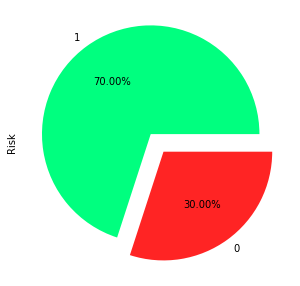

In [47]:
fig,ax=plt.subplots(figsize=(16,5))
dataset["Risk"].value_counts().plot.pie(autopct="%.2f%%",colors=['#00FF7F','#FF2424'],explode = (0.1, 0.1))

<AxesSubplot:ylabel='G'>

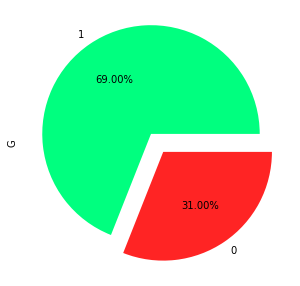

In [51]:
fig,ax=plt.subplots(figsize=(16,5))
dataset["G"].value_counts().plot.pie(autopct="%.2f%%",colors=['#00FF7F','#FF2424'],explode = (0.1, 0.1))

In [48]:
def count_attributecount(columns):
    G_1=[]
    G_0=[]
    B_1=[]
    B_0=[]
    for item in columns:
        good_1= dataset.loc[dataset[item] == 1 ].loc[dataset['Risk']==1]
        good_0= dataset.loc[dataset[item] == 0 ].loc[dataset['Risk']==1]
        bad_1= dataset.loc[dataset[item] == 1 ].loc[dataset['Risk']==0]
        bad_0=dataset.loc[dataset[item] == 0].loc[dataset['Risk']==0]
        G_1.append(good_1.values.shape[0])
        G_0.append(good_0.values.shape[0])
        B_1.append(bad_1.values.shape[0])
        B_0.append(bad_0.values.shape[0])
    return(G_1,G_0,B_1,B_0)

def visualize_decision_per_attribute(Attributes):
    G_1,G_0,B_1,B_0= count_attributecount(Attributes)
    risk_counts = {
        'Good_risk_pos': np.array(G_1),
        'Good_risk_neg': np.array(G_0),
        'Bad_risk_pos': np.array(B_1),
        'Bad_risk_neg': np.array(B_0),
    }
    fig, ax = plt.subplots(figsize=(20,10))
    bottom = np.zeros(9)

    for attr, attr_count in risk_counts.items():
        p = ax.bar(Attributes, attr_count, label=attr, bottom=bottom)
        bottom += attr_count

        ax.bar_label(p, label_type='center')

    ax.set_title('Outcomes per attribute')
    ax.legend()

    plt.show()
    
    
Attributes =["A", "G", "J", "H", "S","B","C","D", "P"]
visualize_decision_per_attribute(Attributes)

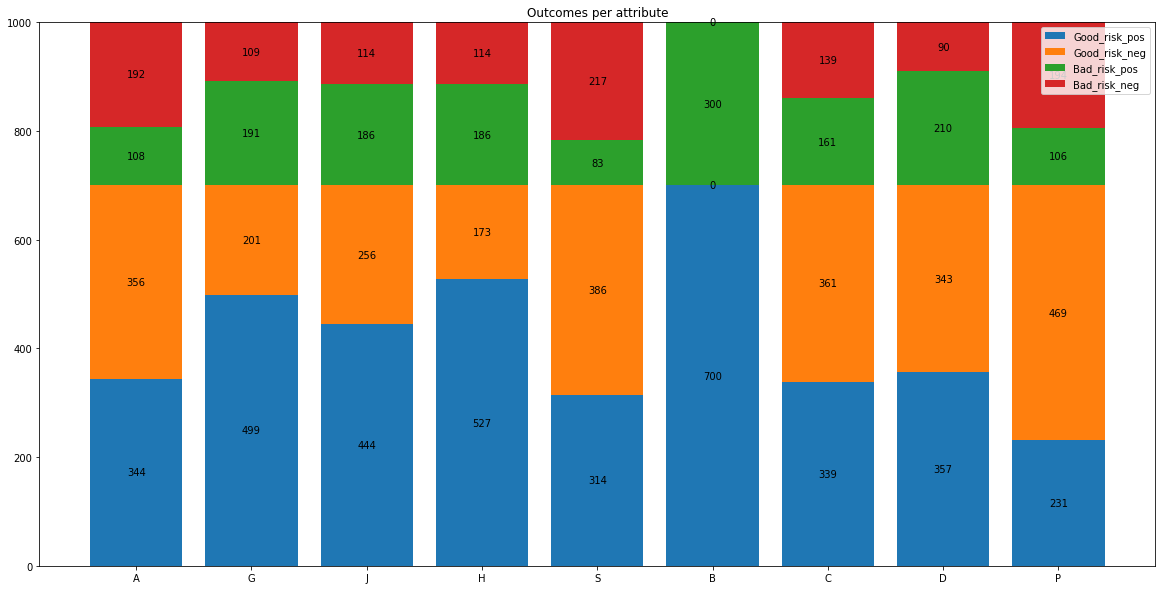

In [50]:
Attributes =["A", "G", "J", "H", "S","B","C","D", "P"]
visualize_decision_per_attribute(Attributes)